# NASDAQ-100 Historical Data — Exploratory Data Analysis

**Dataset:** NASDAQ-100 Historical Data 2000–2026  
**Goal:** Understand the structure, distributions, relationships, and quality of the data before modeling.

---
**Sections:**
1. Setup & Data Loading
2. Dataset Overview
3. Price Trends (Line Charts)
4. Distributions — Histograms & Box Plots
5. Correlation Matrix (OHLC)
6. Missing Values & Outliers

---
## 1. Setup & Data Loading

In [26]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 15,
})

SEED = 42
np.random.seed(SEED)

In [27]:
# ── Load data ────────────────────────────────────────────────────────────────
# Adjust the path to wherever you saved the Kaggle CSV(s).
# The dataset may be a single wide CSV or one file per ticker — handle both.

import os, glob

DATA_PATH = './data'

csv_files = glob.glob(os.path.join(DATA_PATH, '*.csv'))
print(f'Found {len(csv_files)} CSV file(s)')

if len(csv_files) == 1:
    # Single wide file
    df_raw = pd.read_csv(csv_files[0], parse_dates=['Date'])
    print(df_raw.shape)
    df_raw.head(3)
else:
    # One file per ticker — stack into long format
    frames = []
    for f in csv_files:
        tmp = pd.read_csv(f, parse_dates=['Date'])
        tmp['Ticker'] = os.path.splitext(os.path.basename(f))[0]
        frames.append(tmp)
    df_raw = pd.concat(frames, ignore_index=True)
    print(df_raw.shape)
    df_raw.head(3)

Found 1 CSV file(s)
(514075, 8)


In [28]:
# ── Standardise column names ─────────────────────────────────────────────────
df_raw.columns = df_raw.columns.str.strip().str.title()
# Expected columns after normalisation: Date, Open, High, Low, Close, Volume, Ticker
print('Columns:', df_raw.columns.tolist())
print('Tickers:', df_raw['Ticker'].nunique() if 'Ticker' in df_raw.columns else 'N/A')
print('Date range:', df_raw['Date'].min(), '→', df_raw['Date'].max())

Columns: ['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
Tickers: 100
Date range: 2000-01-03 00:00:00 → 2026-02-18 00:00:00


In [29]:
# ── Working copy ─────────────────────────────────────────────────────────────
df = df_raw.copy()
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Convenience: list of unique tickers
TICKERS = df['Ticker'].unique().tolist()

# A handful of representative tickers for detailed plots
SAMPLE_TICKERS = ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'META']
SAMPLE_TICKERS = [t for t in SAMPLE_TICKERS if t in TICKERS]  # keep only present ones
print('Sample tickers for detailed plots:', SAMPLE_TICKERS)

Sample tickers for detailed plots: ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'META']


---
## 2. Dataset Overview

In [30]:
print('=== Basic info ===')
print(f'Rows       : {len(df):,}')
print(f'Columns    : {df.columns.tolist()}')
print(f'Tickers    : {len(TICKERS)}')
print(f'Date range : {df["Date"].min().date()} → {df["Date"].max().date()}')
print()
df.dtypes

=== Basic info ===
Rows       : 514,075
Columns    : ['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
Tickers    : 100
Date range : 2000-01-03 → 2026-02-18



Ticker                  str
Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

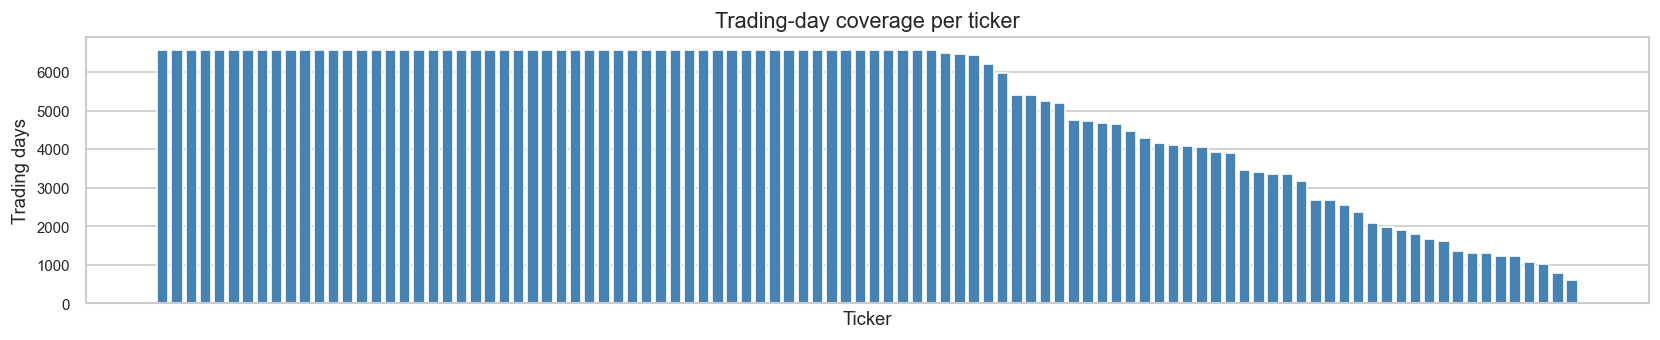

Min coverage: 609 | Max coverage: 6571


In [31]:
# Rows per ticker (trading days coverage)
rows_per_ticker = df.groupby('Ticker').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(rows_per_ticker.index, rows_per_ticker.values, width=0.8, color='steelblue')
ax.set_xlabel('Ticker')
ax.set_ylabel('Trading days')
ax.set_title('Trading-day coverage per ticker')
ax.set_xticks([])
plt.tight_layout()
plt.show()

print('Min coverage:', rows_per_ticker.min(), '| Max coverage:', rows_per_ticker.max())

In [32]:
# Summary statistics for OHLCV
df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2)

,Open,High,Low,Close,Volume
count,514075.00,514075.00,514075.00,514075.00,5.140750e+05
mean,100.18,101.49,98.83,100.19,2.596485e+07
std,241.28,244.18,238.27,241.29,1.087908e+08
min,0.03,0.03,0.03,0.03,0.000000e+00
25%,17.99,18.27,17.70,17.99,1.653700e+06
50%,40.77,41.32,40.24,40.80,3.758500e+06
75%,96.82,98.04,95.58,96.85,1.056520e+07
max,5815.00,5839.41,5707.93,5815.92,9.230856e+09


---
## 3. Price Trends — Line Charts

Line charts show **how prices evolve over time**.  
We look at:
- Adjusted close price for individual tickers (absolute level)
- Normalised price (rebased to 100) so all tickers can be compared on the same axis
- The full NASDAQ-100 composite (if an index column is present, otherwise median close)

Key market events visible in this data: dot-com crash (2000–2002), GFC (2008–2009), COVID crash (2020), rate-hike bear market (2022).

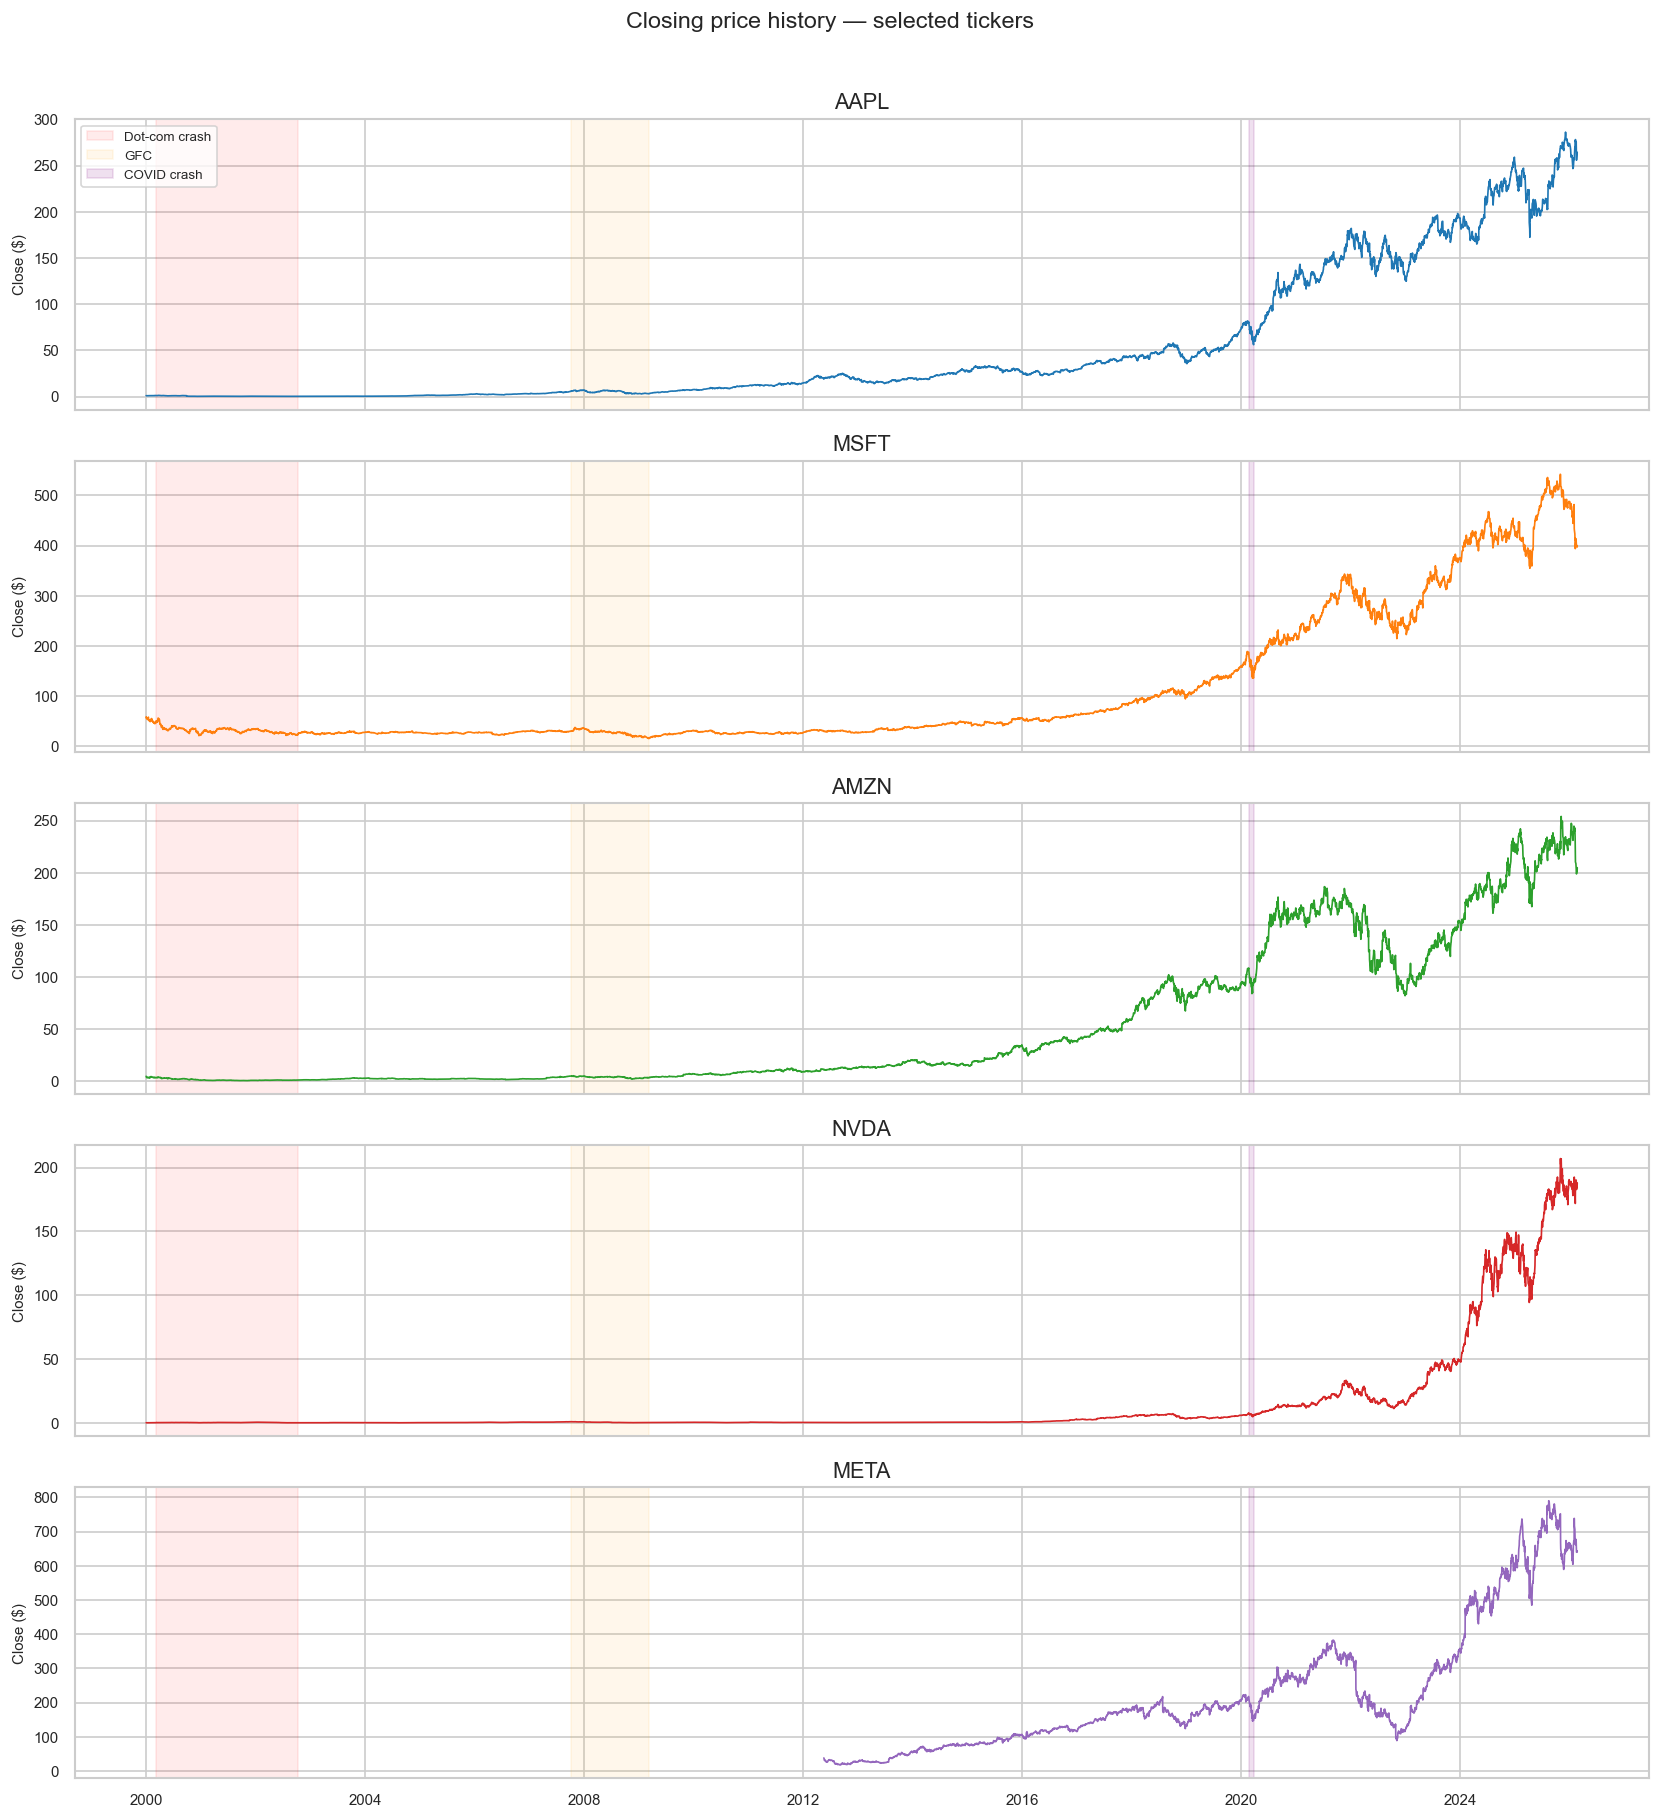

In [33]:
# ── 3.1  Individual closing price trends ─────────────────────────────────────
fig, axes = plt.subplots(len(SAMPLE_TICKERS), 1,
                         figsize=(14, 3 * len(SAMPLE_TICKERS)),
                         sharex=True)

if len(SAMPLE_TICKERS) == 1:
    axes = [axes]

palette = sns.color_palette('tab10', len(SAMPLE_TICKERS))

for ax, ticker, color in zip(axes, SAMPLE_TICKERS, palette):
    sub = df[df['Ticker'] == ticker]
    ax.plot(sub['Date'], sub['Close'], lw=1, color=color)
    ax.set_ylabel('Close ($)', fontsize=9)
    ax.set_title(ticker)
    # Shade major bear markets
    ax.axvspan(pd.Timestamp('2000-03-10'), pd.Timestamp('2002-10-09'),
               alpha=0.08, color='red', label='Dot-com crash')
    ax.axvspan(pd.Timestamp('2007-10-09'), pd.Timestamp('2009-03-09'),
               alpha=0.08, color='orange', label='GFC')
    ax.axvspan(pd.Timestamp('2020-02-19'), pd.Timestamp('2020-03-23'),
               alpha=0.12, color='purple', label='COVID crash')

axes[0].legend(loc='upper left', fontsize=8)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Closing price history — selected tickers', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

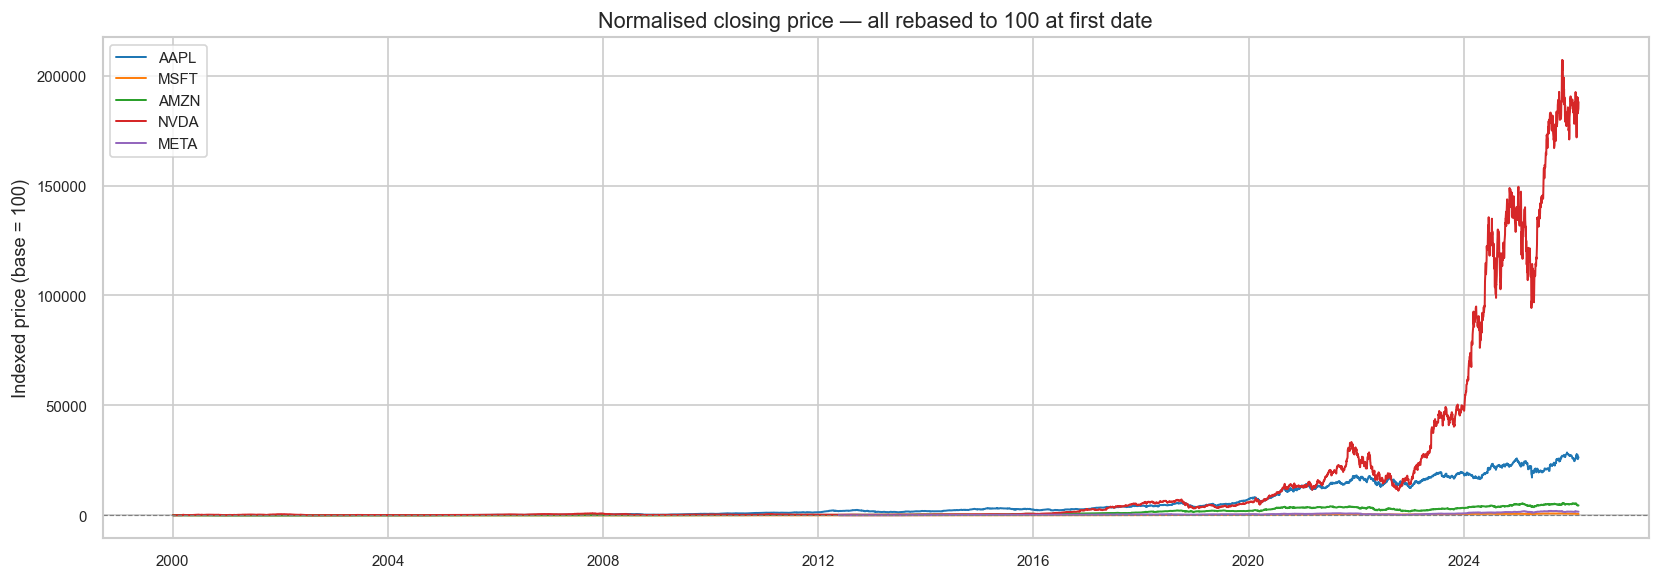


Interpretation:
  - Values above 100 mean the stock has grown since the start date.
  - Rebasing removes the distortion caused by different absolute price levels
    (e.g. comparing a $3 stock with a $3,000 stock on the same chart).
  - Steeper slopes = faster compounding growth.



In [34]:
# ── 3.2  Normalised price (rebased to 100 at first available date) ────────────
# This removes the price-level effect so growth rates are comparable.

fig, ax = plt.subplots(figsize=(14, 5))
palette = sns.color_palette('tab10', len(SAMPLE_TICKERS))

for ticker, color in zip(SAMPLE_TICKERS, palette):
    sub = df[df['Ticker'] == ticker].set_index('Date')['Close']
    normalised = sub / sub.iloc[0] * 100
    ax.plot(normalised, lw=1.2, label=ticker, color=color)

ax.axhline(100, color='gray', lw=0.7, linestyle='--')
ax.set_ylabel('Indexed price (base = 100)')
ax.set_title('Normalised closing price — all rebased to 100 at first date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Values above 100 mean the stock has grown since the start date.
  - Rebasing removes the distortion caused by different absolute price levels
    (e.g. comparing a $3 stock with a $3,000 stock on the same chart).
  - Steeper slopes = faster compounding growth.
""")

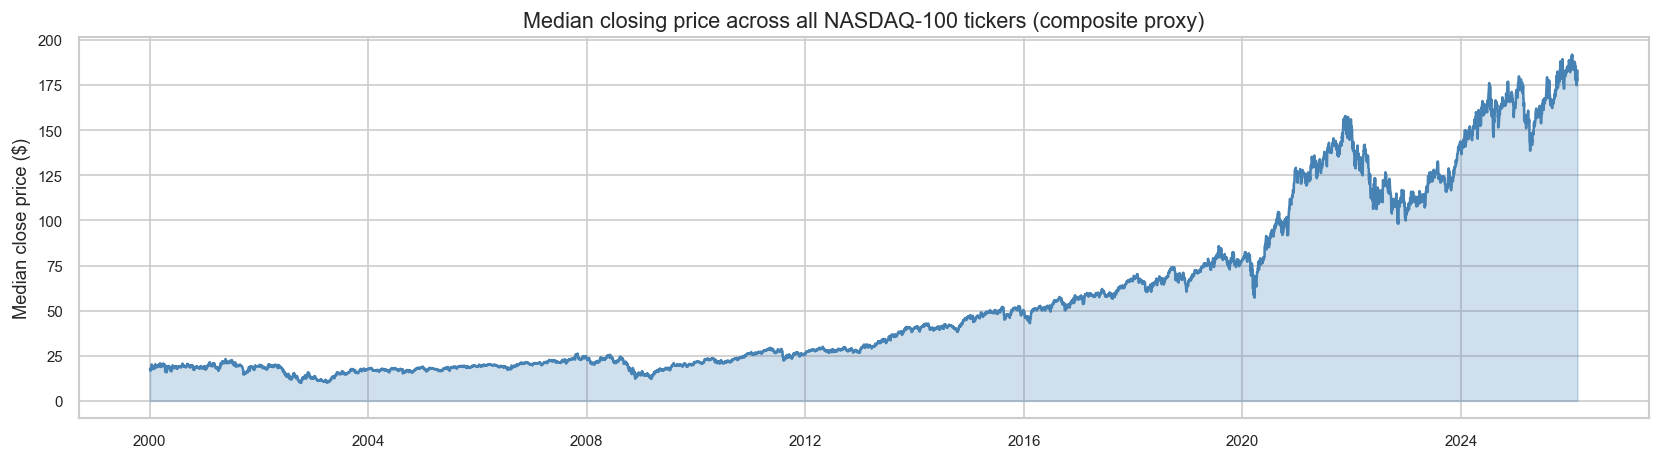


Interpretation:
  - Using the median (not mean) makes this resistant to extreme outliers
    like NVDA's recent >$500 price.
  - The shape mirrors the NASDAQ-100 index: the three major drawdowns
    (dot-com, GFC, COVID) are clearly visible as sharp drops.



In [35]:
# ── 3.3  Median close across all tickers (NASDAQ-100 composite proxy) ─────────
median_close = df.groupby('Date')['Close'].median()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(median_close.index, median_close, alpha=0.25, color='steelblue')
ax.plot(median_close, lw=1.5, color='steelblue')
ax.set_ylabel('Median close price ($)')
ax.set_title('Median closing price across all NASDAQ-100 tickers (composite proxy)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Using the median (not mean) makes this resistant to extreme outliers
    like NVDA's recent >$500 price.
  - The shape mirrors the NASDAQ-100 index: the three major drawdowns
    (dot-com, GFC, COVID) are clearly visible as sharp drops.
""")

---
## 4. Distributions — Histograms & Box Plots

We examine five distributions:

| Distribution | Why it matters |
|---|---|
| **Daily log returns** | Core signal for forecasting; shows fat tails / non-normality |
| **Closing price** | Raw price level — heavily right-skewed due to long-term compounding |
| **Daily volume** | Liquidity proxy; spikes signal events |
| **Daily price range** (High − Low) | Intraday volatility |
| **Rolling 30-day volatility** | Regime-level risk |

Each plot includes a **written interpretation**.

In [36]:
# ── Compute derived columns ──────────────────────────────────────────────────
df = df.sort_values(['Ticker', 'Date'])
df['Log_Return'] = df.groupby('Ticker')['Close'].transform(
    lambda x: np.log(x / x.shift(1))
)
df['Price_Range'] = df['High'] - df['Low']
df['Vol_30d'] = df.groupby('Ticker')['Log_Return'].transform(
    lambda x: x.rolling(30).std() * np.sqrt(252)  # annualised
)
df.head(3)

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Log_Return,Price_Range,Vol_30d
0,AAPL,2000-01-03,0.94,1.00,0.91,1.00,0.84,535796800,NaN,0.09,NaN
1,AAPL,2000-01-04,0.97,0.99,0.90,0.92,0.77,512377600,-0.083382,0.09,NaN
2,AAPL,2000-01-05,0.93,0.99,0.92,0.93,0.78,778321600,0.010811,0.07,NaN


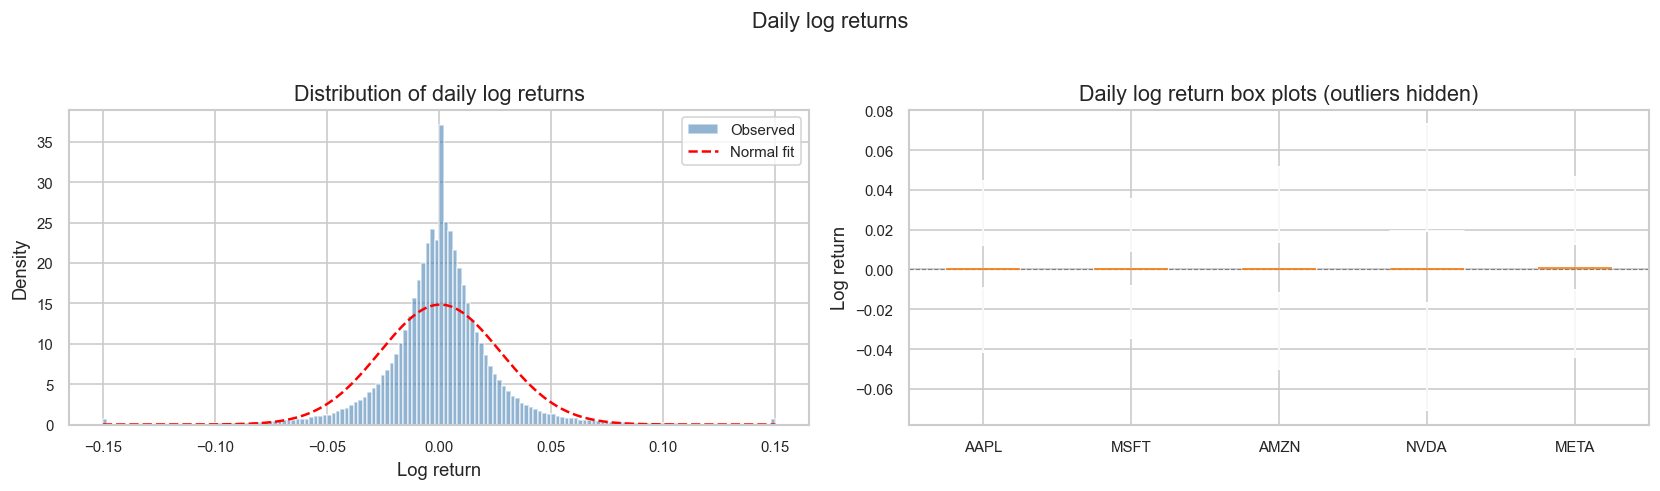

Skewness: -0.845  |  Excess kurtosis: 54.816

Interpretation:
  - The histogram is narrower and taller than the normal curve (leptokurtic).
    Excess kurtosis >> 0 confirms heavy tails — extreme returns happen far
    more often than a normal distribution would predict.
  - Slight negative skew: large down-days are more extreme than large up-days
    (well-known 'negative skewness' of equity returns).
  - Box plots: the median return is close to zero for all tickers; differences
    in box width reflect each stock's typical daily volatility.
  - Implication for modelling: use log returns (not raw price changes) to
    stabilise variance. Consider robust loss functions (Huber, quantile)
    that handle fat tails.



In [37]:
# ── 4.1  Daily log returns ────────────────────────────────────────────────────
returns = df['Log_Return'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Histogram + KDE vs Normal
ax1.hist(returns.clip(-0.15, 0.15), bins=150, density=True,
         color='steelblue', alpha=0.6, label='Observed')
x = np.linspace(-0.15, 0.15, 300)
ax1.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
         'r--', lw=1.5, label='Normal fit')
ax1.set_xlabel('Log return')
ax1.set_ylabel('Density')
ax1.set_title('Distribution of daily log returns')
ax1.legend()

# Box plot per sample ticker
sample_returns = [
    df[df['Ticker'] == t]['Log_Return'].dropna().values
    for t in SAMPLE_TICKERS
]
ax2.boxplot(sample_returns, labels=SAMPLE_TICKERS, showfliers=False)
ax2.axhline(0, color='gray', lw=0.7, linestyle='--')
ax2.set_ylabel('Log return')
ax2.set_title('Daily log return box plots (outliers hidden)')

plt.suptitle('Daily log returns', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

kurt = returns.kurtosis()
skew = returns.skew()
print(f'Skewness: {skew:.3f}  |  Excess kurtosis: {kurt:.3f}')
print("""
Interpretation:
  - The histogram is narrower and taller than the normal curve (leptokurtic).
    Excess kurtosis >> 0 confirms heavy tails — extreme returns happen far
    more often than a normal distribution would predict.
  - Slight negative skew: large down-days are more extreme than large up-days
    (well-known 'negative skewness' of equity returns).
  - Box plots: the median return is close to zero for all tickers; differences
    in box width reflect each stock's typical daily volatility.
  - Implication for modelling: use log returns (not raw price changes) to
    stabilise variance. Consider robust loss functions (Huber, quantile)
    that handle fat tails.
""")

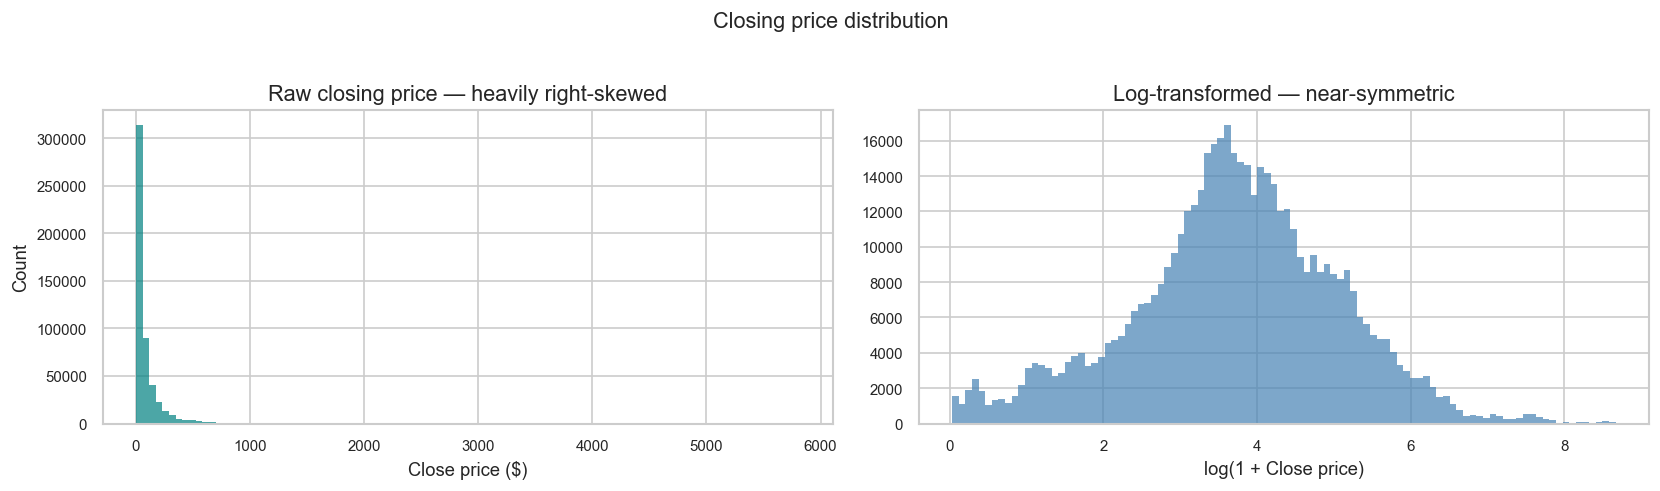

Mean close: $100.19  |  Median close: $40.80
Max close:  $5815.92  (likely NVDA or similar post-split adjusted)

Interpretation:
  - Raw closing prices are strongly right-skewed: most stocks trade in
    a low price band, while a few (NVDA, AMZN pre-split) sit far to the right.
  - Mean >> Median confirms the right skew (outliers pull the mean up).
  - After a log transform the distribution becomes roughly symmetric —
    justifying why models trained on log prices / log returns behave better
    than models trained on raw dollar prices.
  - Box plot would show many right-side outliers; this is expected and NOT
    a data quality problem — it reflects genuine price dispersion.



In [38]:
# ── 4.2  Closing price distribution ─────────────────────────────────────────
closes = df['Close'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Raw histogram
ax1.hist(closes, bins=100, color='teal', alpha=0.7, edgecolor='none')
ax1.set_xlabel('Close price ($)')
ax1.set_ylabel('Count')
ax1.set_title('Raw closing price — heavily right-skewed')

# Log-scale histogram
ax2.hist(np.log1p(closes), bins=100, color='steelblue', alpha=0.7, edgecolor='none')
ax2.set_xlabel('log(1 + Close price)')
ax2.set_title('Log-transformed — near-symmetric')

plt.suptitle('Closing price distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean close: ${closes.mean():.2f}  |  Median close: ${closes.median():.2f}')
print(f'Max close:  ${closes.max():.2f}  (likely NVDA or similar post-split adjusted)')
print("""
Interpretation:
  - Raw closing prices are strongly right-skewed: most stocks trade in
    a low price band, while a few (NVDA, AMZN pre-split) sit far to the right.
  - Mean >> Median confirms the right skew (outliers pull the mean up).
  - After a log transform the distribution becomes roughly symmetric —
    justifying why models trained on log prices / log returns behave better
    than models trained on raw dollar prices.
  - Box plot would show many right-side outliers; this is expected and NOT
    a data quality problem — it reflects genuine price dispersion.
""")

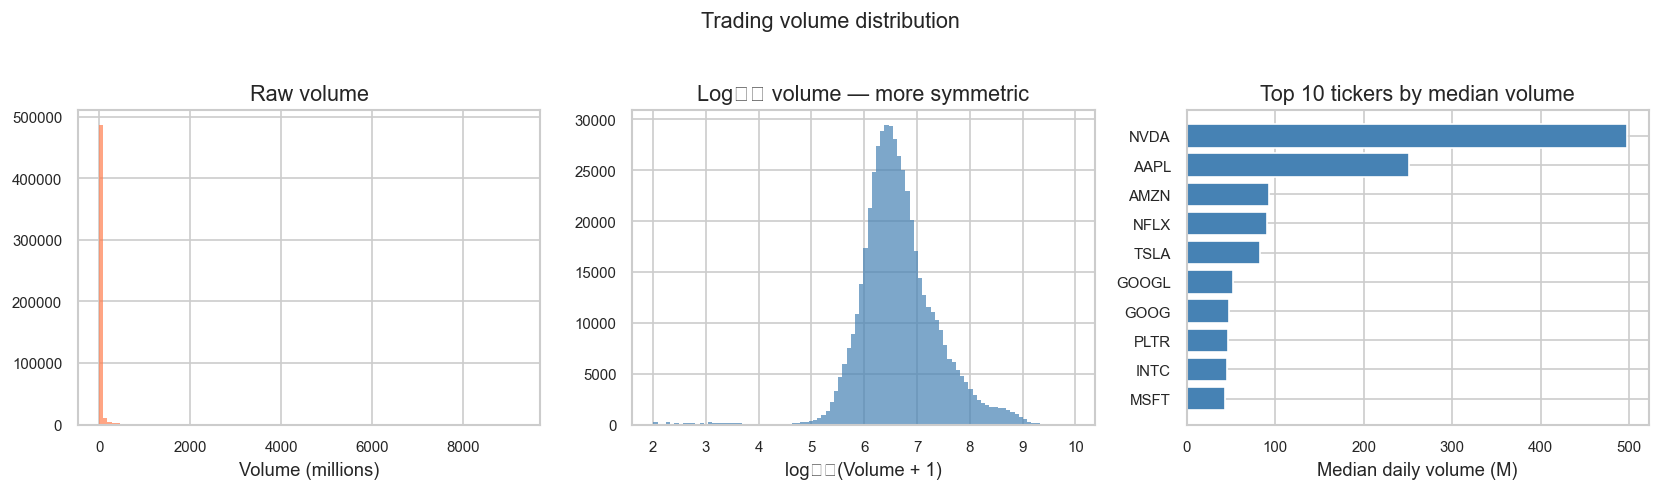


Interpretation:
  - Raw volume is extremely right-skewed: a small number of days/stocks
    have huge volume spikes (earnings releases, index rebalancing, macro events).
  - Log₁₀ transform compresses this to a roughly bell-shaped distribution,
    making volume usable as a model feature without normalisation issues.
  - Zero-volume days (filtered out above) indicate exchange closures or data
    gaps — these will be handled in preprocessing.
  - High-volume tickers (AAPL, NVDA, MSFT) are the most liquid and have the
    cleanest price discovery — generally better for forecasting.



In [39]:
# ── 4.3  Daily trading volume ─────────────────────────────────────────────────
volume = df['Volume'].replace(0, np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(volume / 1e6, bins=100, color='coral', alpha=0.7, edgecolor='none')
axes[0].set_xlabel('Volume (millions)')
axes[0].set_title('Raw volume')

axes[1].hist(np.log10(volume + 1), bins=100, color='steelblue', alpha=0.7, edgecolor='none')
axes[1].set_xlabel('log₁₀(Volume + 1)')
axes[1].set_title('Log₁₀ volume — more symmetric')

# Volume by ticker (top 10 by median volume)
top_vol = (df.groupby('Ticker')['Volume']
             .median()
             .sort_values(ascending=False)
             .head(10))
axes[2].barh(top_vol.index[::-1], top_vol.values[::-1] / 1e6, color='steelblue')
axes[2].set_xlabel('Median daily volume (M)')
axes[2].set_title('Top 10 tickers by median volume')

plt.suptitle('Trading volume distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Raw volume is extremely right-skewed: a small number of days/stocks
    have huge volume spikes (earnings releases, index rebalancing, macro events).
  - Log₁₀ transform compresses this to a roughly bell-shaped distribution,
    making volume usable as a model feature without normalisation issues.
  - Zero-volume days (filtered out above) indicate exchange closures or data
    gaps — these will be handled in preprocessing.
  - High-volume tickers (AAPL, NVDA, MSFT) are the most liquid and have the
    cleanest price discovery — generally better for forecasting.
""")

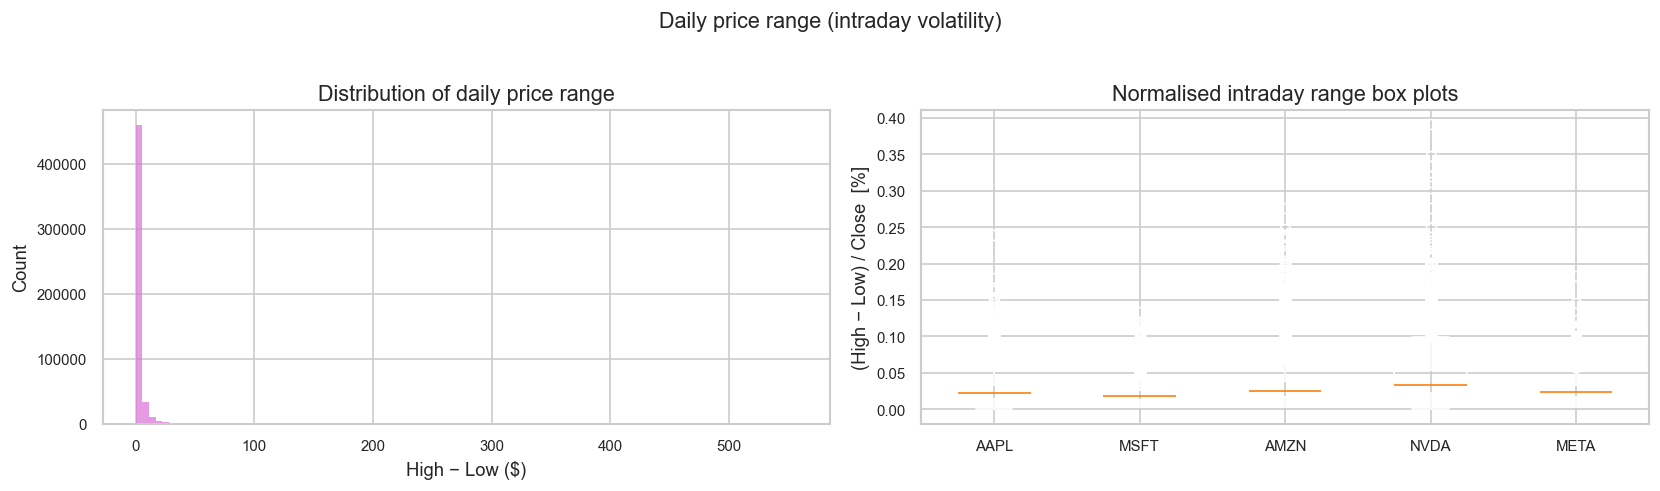


Interpretation:
  - The raw range is right-skewed (same reason as price: expensive stocks
    have larger absolute dollar swings).
  - After normalising by close price (relative range), tickers are comparable.
    A 2% daily range is typical; values above 5–10% indicate volatile sessions.
  - Wider boxes = stocks with more intraday volatility — important for risk
    management features in the RecSys model.
  - Outliers in the box plot correspond to extreme news events (earnings
    surprises, macro shocks) and are real signals, not data errors.



In [40]:
# ── 4.4  Daily price range (High − Low) ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

price_range = df['Price_Range'].dropna()

ax1.hist(price_range, bins=100, color='orchid', alpha=0.7, edgecolor='none')
ax1.set_xlabel('High − Low ($)')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of daily price range')

# Box plot per sample ticker (normalised by close to make comparable)
norm_ranges = [
    (df[df['Ticker'] == t]['Price_Range'] / df[df['Ticker'] == t]['Close']).dropna().values
    for t in SAMPLE_TICKERS
]
ax2.boxplot(norm_ranges, labels=SAMPLE_TICKERS)
ax2.set_ylabel('(High − Low) / Close  [%]')
ax2.set_title('Normalised intraday range box plots')

plt.suptitle('Daily price range (intraday volatility)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - The raw range is right-skewed (same reason as price: expensive stocks
    have larger absolute dollar swings).
  - After normalising by close price (relative range), tickers are comparable.
    A 2% daily range is typical; values above 5–10% indicate volatile sessions.
  - Wider boxes = stocks with more intraday volatility — important for risk
    management features in the RecSys model.
  - Outliers in the box plot correspond to extreme news events (earnings
    surprises, macro shocks) and are real signals, not data errors.
""")

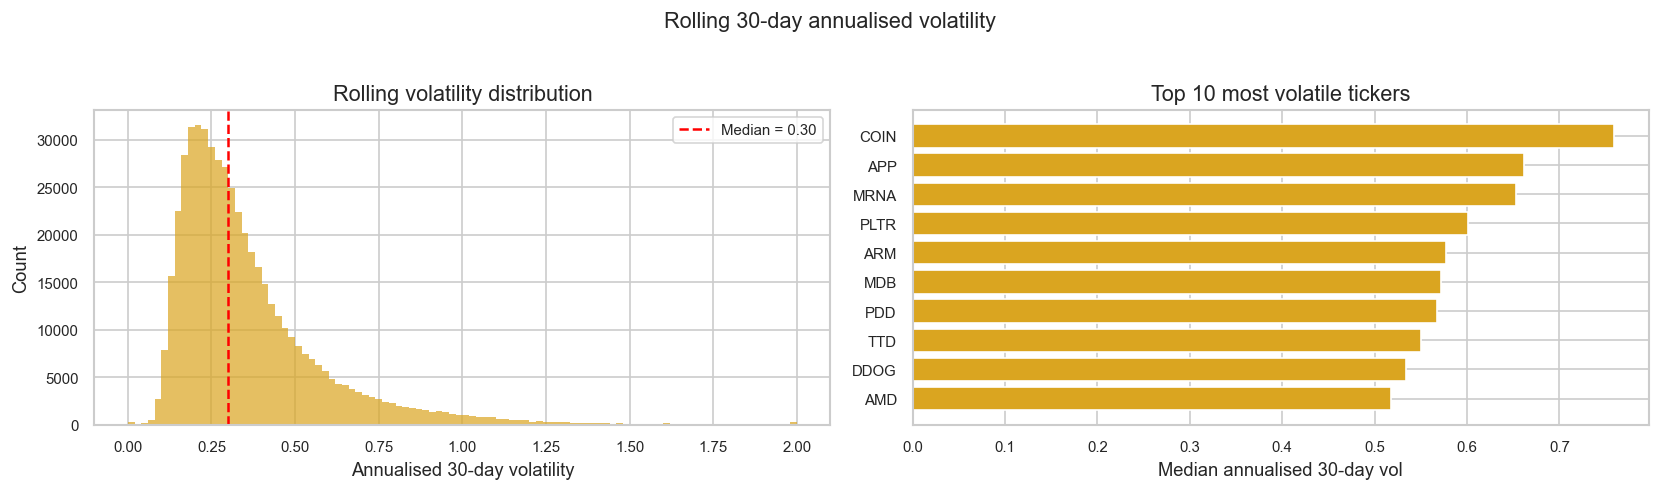


Interpretation:
  - Most tickers have annualised volatility between 0.2 (20%) and 0.6 (60%).
    Values above 1.0 (100%) reflect periods of extreme stress or thinly-traded
    smaller-cap names in the index.
  - The right tail (high vol) corresponds to crisis periods and high-beta
    growth stocks (NVDA, TSLA-class names).
  - Volatility is itself a useful feature: models that take vol as input can
    adaptively widen their prediction intervals during stressed periods.
  - Bimodal shape (two humps) is common: one mode for 'calm' regimes
    and one for 'stressed' regimes — a volatility-regime feature may help.



In [41]:
# ── 4.5  Rolling 30-day annualised volatility ─────────────────────────────────
vol_data = df['Vol_30d'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(vol_data.clip(0, 2), bins=100, color='goldenrod', alpha=0.7, edgecolor='none')
ax1.axvline(vol_data.median(), color='red', lw=1.5, linestyle='--', label=f'Median = {vol_data.median():.2f}')
ax1.set_xlabel('Annualised 30-day volatility')
ax1.set_ylabel('Count')
ax1.set_title('Rolling volatility distribution')
ax1.legend()

# Per-ticker median vol (top 10 most volatile)
tick_vol = df.groupby('Ticker')['Vol_30d'].median().sort_values(ascending=False).head(10)
ax2.barh(tick_vol.index[::-1], tick_vol.values[::-1], color='goldenrod')
ax2.set_xlabel('Median annualised 30-day vol')
ax2.set_title('Top 10 most volatile tickers')

plt.suptitle('Rolling 30-day annualised volatility', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Most tickers have annualised volatility between 0.2 (20%) and 0.6 (60%).
    Values above 1.0 (100%) reflect periods of extreme stress or thinly-traded
    smaller-cap names in the index.
  - The right tail (high vol) corresponds to crisis periods and high-beta
    growth stocks (NVDA, TSLA-class names).
  - Volatility is itself a useful feature: models that take vol as input can
    adaptively widen their prediction intervals during stressed periods.
  - Bimodal shape (two humps) is common: one mode for 'calm' regimes
    and one for 'stressed' regimes — a volatility-regime feature may help.
""")

---
## 5. Correlation Matrix — OHLC

We compute two correlation matrices:
1. **Within-ticker OHLC correlation** — how Open, High, Low, Close move together for the same stock
2. **Cross-ticker Close price correlation** — which stocks move together (sector clustering)

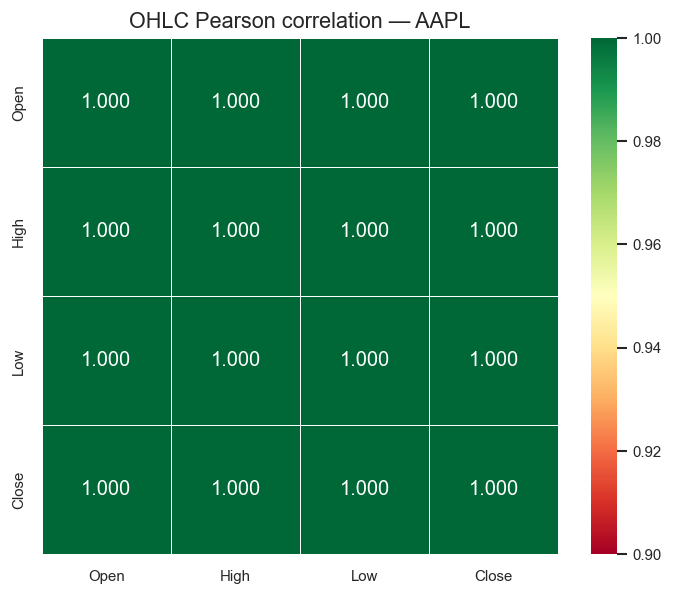


Interpretation:
  - All OHLC columns are highly correlated (>0.99 typically).
    This is expected: a stock that opens high tends to close high
    because all four prices track the same underlying asset value.
  - Open–Close correlation is slightly lower than High–Close because
    intraday moves can reverse direction.
  - High–Low correlation is very high but not 1.0: on volatile days the
    spread widens even if close ends near open.
  - Implication: using all four OHLC columns as separate model features
    introduces multicollinearity. Prefer derived features like midpoint
    ((H+L)/2), body size (|C-O|), and shadow size (H-max(O,C)).



In [42]:
# ── 5.1  Within-ticker OHLC Pearson correlation ───────────────────────────────
# Use a single, well-covered ticker as the representative example
ref_ticker = SAMPLE_TICKERS[0] if SAMPLE_TICKERS else TICKERS[0]
ohlc = df[df['Ticker'] == ref_ticker][['Open', 'High', 'Low', 'Close']].dropna()
corr_ohlc = ohlc.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_ohlc, dtype=bool), k=1)  # show lower triangle only
sns.heatmap(corr_ohlc, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.9, vmax=1.0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title(f'OHLC Pearson correlation — {ref_ticker}')
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - All OHLC columns are highly correlated (>0.99 typically).
    This is expected: a stock that opens high tends to close high
    because all four prices track the same underlying asset value.
  - Open–Close correlation is slightly lower than High–Close because
    intraday moves can reverse direction.
  - High–Low correlation is very high but not 1.0: on volatile days the
    spread widens even if close ends near open.
  - Implication: using all four OHLC columns as separate model features
    introduces multicollinearity. Prefer derived features like midpoint
    ((H+L)/2), body size (|C-O|), and shadow size (H-max(O,C)).
""")

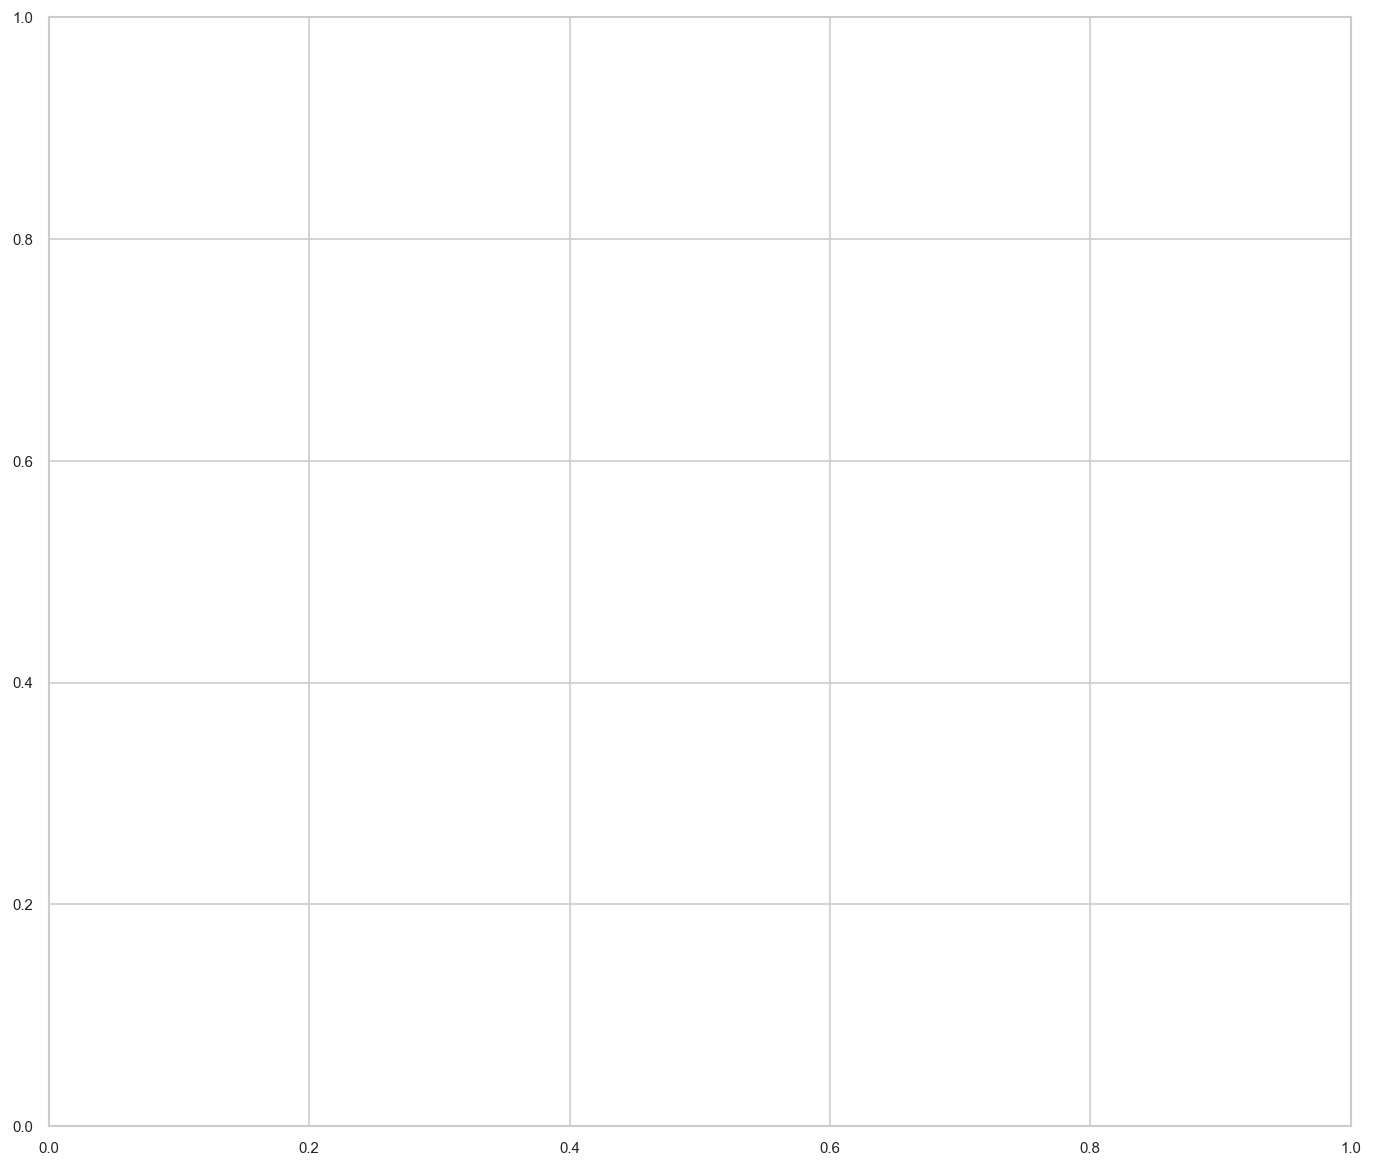

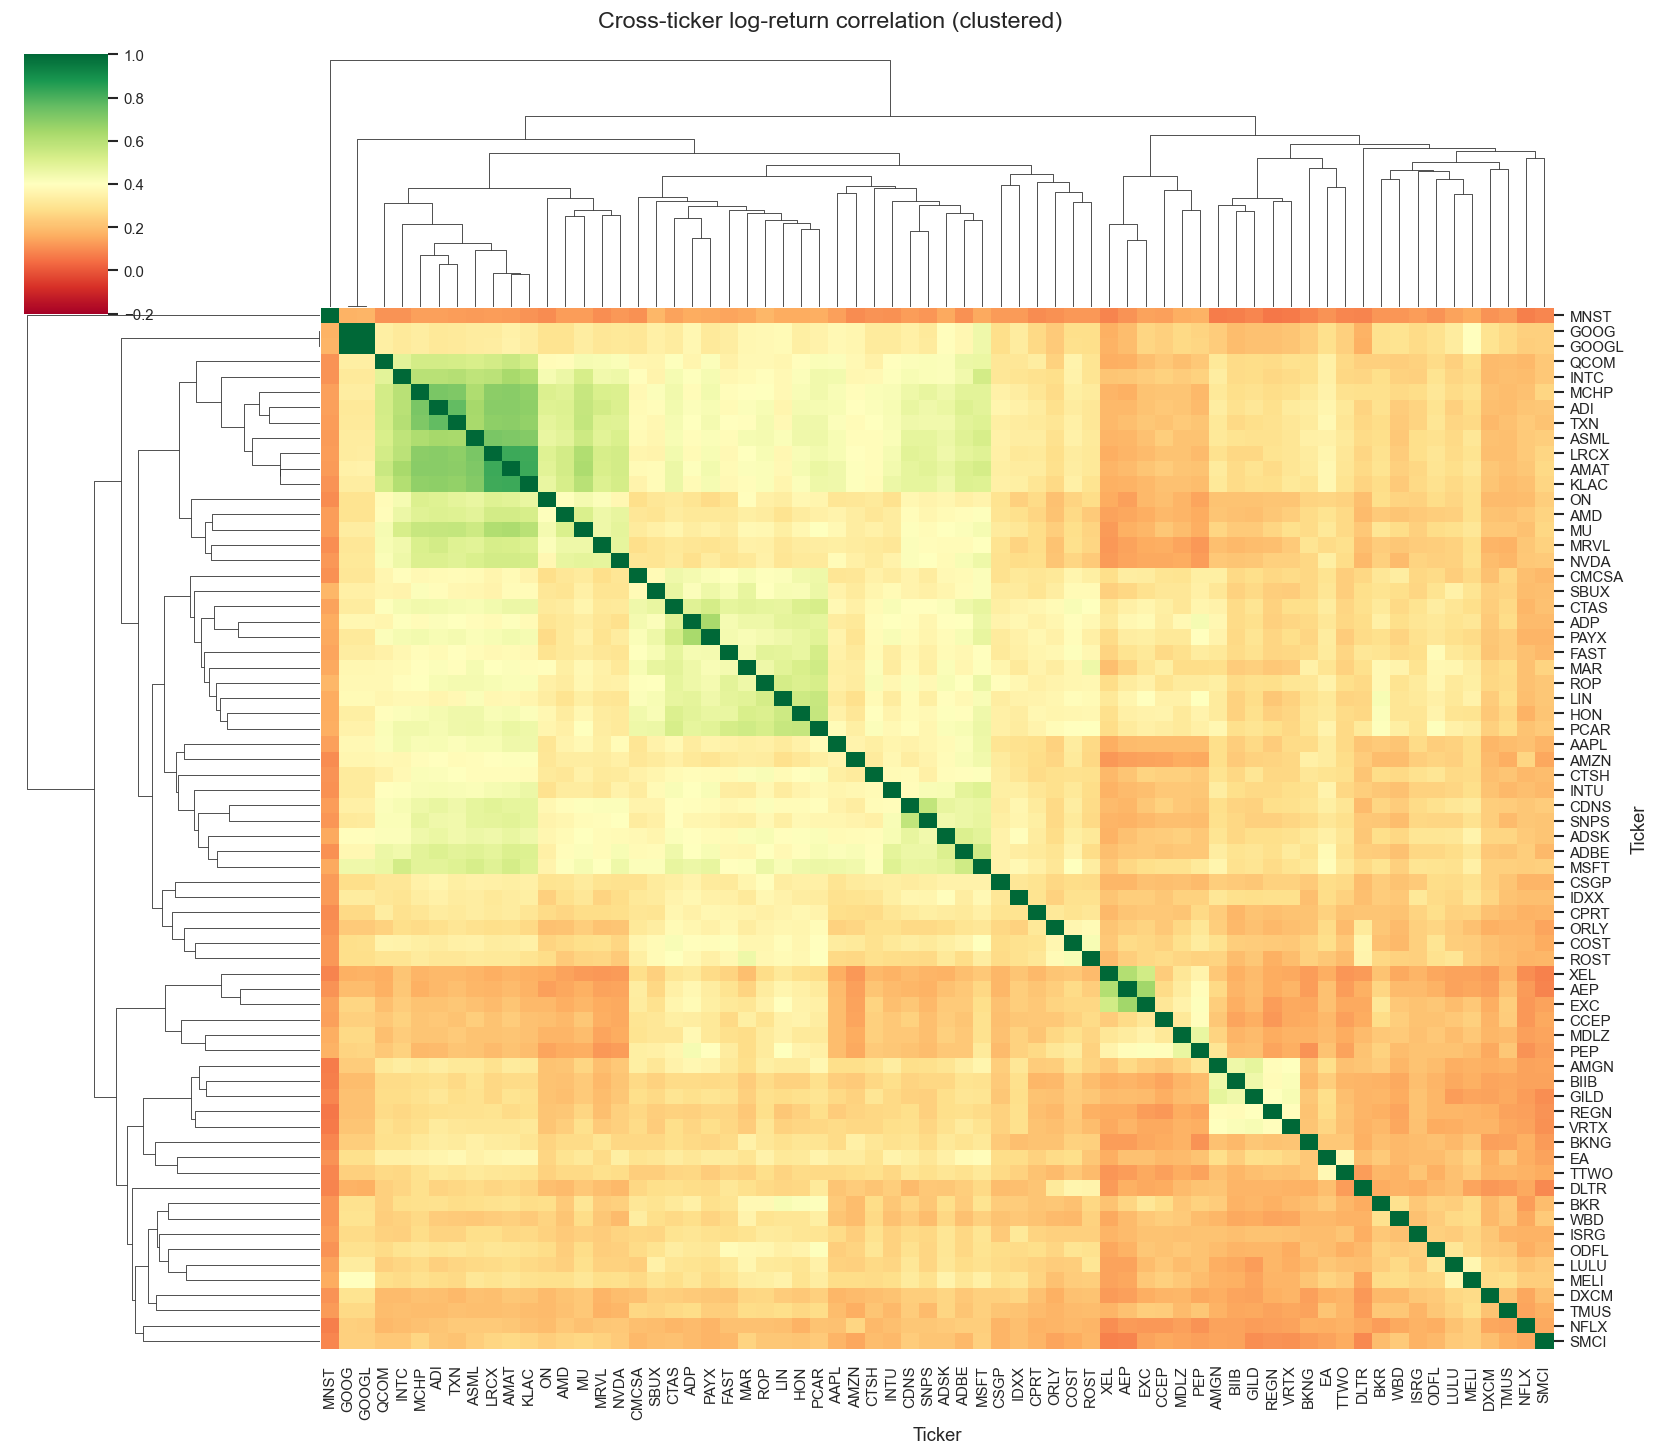


Interpretation:
  - High positive correlation (green) between tickers = they tend to rise
    and fall together. Clustering reveals de-facto sector groupings:
    semiconductors (NVDA, AMD, INTC), megacap tech (AAPL, MSFT, GOOGL),
    biotech names, etc.
  - Near-zero or negative correlation (red) = diversification opportunities;
    also indicates tickers driven by different fundamentals.
  - For the RecSys model: highly correlated tickers can be treated as
    'similar items' in a content-based filter. The correlation matrix
    is itself a similarity matrix we can exploit.
  - Low-correlation clusters are useful for portfolio-diversification
    recommendations — a RecSys that recommends stocks unlike the ones
    a user already holds.



In [43]:
# ── 5.2  Cross-ticker closing price correlation (returns-based) ───────────────
# Build a pivot: Date × Ticker → log return
pivot = (df.pivot_table(index='Date', columns='Ticker', values='Log_Return')
           .dropna(axis=1, thresh=int(0.7 * df['Date'].nunique()))  # drop sparse tickers
           .fillna(0))

cross_corr = pivot.corr()

fig, ax = plt.subplots(figsize=(14, 12))
# Cluster the heatmap so related tickers group together
sns.clustermap(cross_corr, cmap='RdYlGn', vmin=-0.2, vmax=1.0,
               figsize=(14, 12), linewidths=0,
               xticklabels=True, yticklabels=True)
plt.suptitle('Cross-ticker log-return correlation (clustered)', y=1.01, fontsize=14)
plt.show()

print("""
Interpretation:
  - High positive correlation (green) between tickers = they tend to rise
    and fall together. Clustering reveals de-facto sector groupings:
    semiconductors (NVDA, AMD, INTC), megacap tech (AAPL, MSFT, GOOGL),
    biotech names, etc.
  - Near-zero or negative correlation (red) = diversification opportunities;
    also indicates tickers driven by different fundamentals.
  - For the RecSys model: highly correlated tickers can be treated as
    'similar items' in a content-based filter. The correlation matrix
    is itself a similarity matrix we can exploit.
  - Low-correlation clusters are useful for portfolio-diversification
    recommendations — a RecSys that recommends stocks unlike the ones
    a user already holds.
""")

In [44]:
# ── 5.3  Most and least correlated pairs ─────────────────────────────────────
# Flatten upper triangle
corr_pairs = (
    cross_corr.rename_axis(index='Ticker_A', columns='Ticker_B')
    .where(np.triu(np.ones(cross_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index(name='Correlation')
)

print('Top 10 most correlated pairs:')
print(corr_pairs.sort_values('Correlation', ascending=False).head(10).to_string(index=False))
print()
print('Top 10 least correlated pairs:')
print(corr_pairs.sort_values('Correlation').head(10).to_string(index=False))

Top 10 most correlated pairs:
Ticker_A Ticker_B  Correlation
    GOOG    GOOGL     0.997072
    AMAT     KLAC     0.825434
    AMAT     LRCX     0.822702
    KLAC     LRCX     0.818207
     ADI      TXN     0.762574
    ASML     LRCX     0.720795
     ADI     MCHP     0.719213
    AMAT     ASML     0.712948
    MCHP      TXN     0.711373
    ASML     KLAC     0.701785

Top 10 least correlated pairs:
Ticker_A Ticker_B  Correlation
    MNST     REGN     0.058274
    MNST     VRTX     0.064804
    AMGN     MNST     0.070460
    MNST     NFLX     0.072057
    BIIB     MNST     0.073306
    SMCI      XEL     0.080138
    MNST      XEL     0.082190
     AEP     SMCI     0.084854
    DLTR     MNST     0.085848
    GILD     MNST     0.087952


---
## 6. Missing Values & Outliers

### 6.1 Missing values
Missing data in financial time-series can arise from:
- Exchange holidays (expected — not a quality problem)
- Tickers added/removed from the index mid-period (survivorship bias)
- Data provider gaps (genuine quality issue)

### 6.2 Outliers
Outliers in OHLCV data fall into two categories:
- **Legitimate extremes** — crash days, earnings beats, COVID shock → keep them
- **Data errors** — spike to 0 or to 100× normal price, zero volume on a trading day → flag & fix

=== Missing value summary ===
             Count  Pct %
Ticker           0   0.00
Date             0   0.00
Open             0   0.00
High             0   0.00
Low              0   0.00
Close            0   0.00
Adj Close        0   0.00
Volume           0   0.00
Log_Return     100   0.02
Price_Range      0   0.00
Vol_30d       3000   0.58


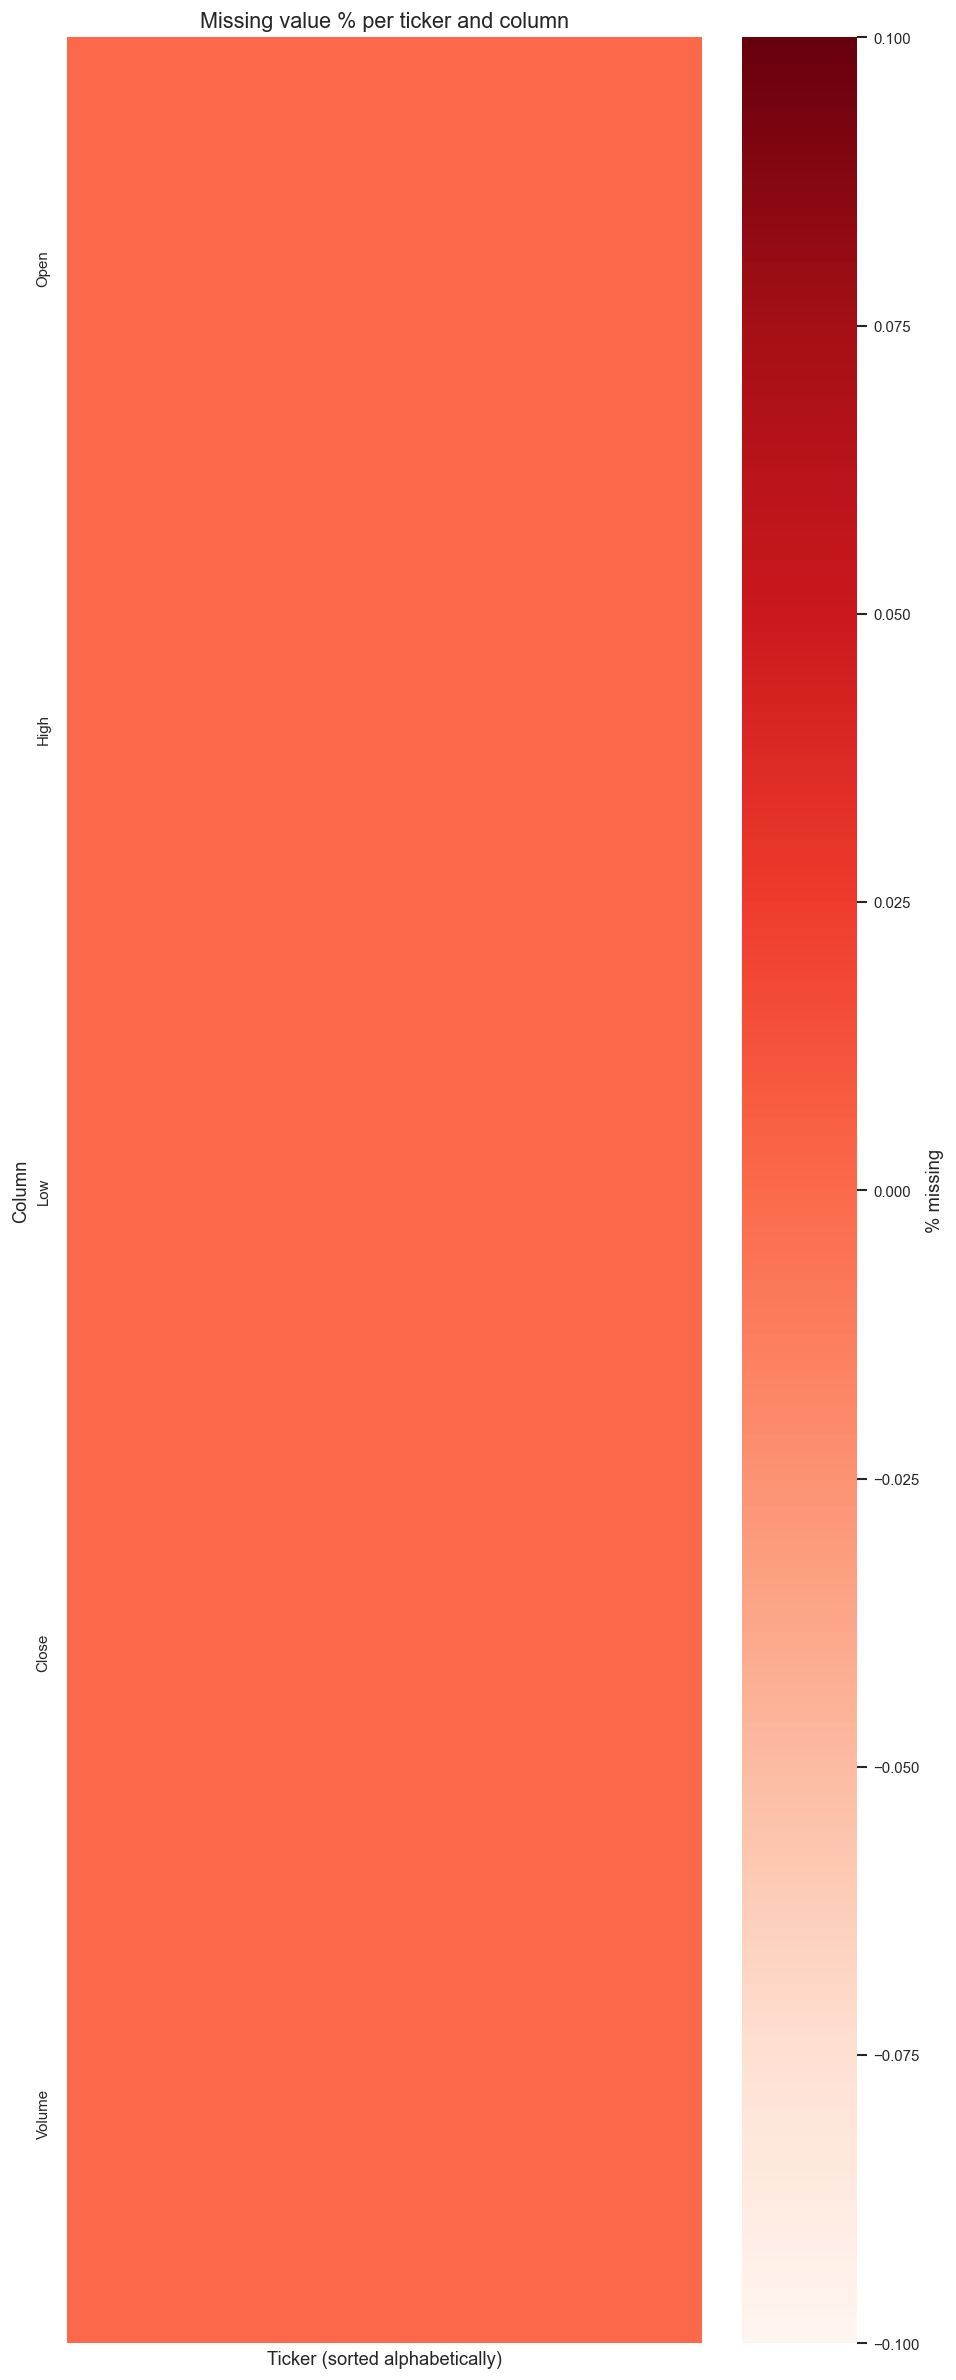


Interpretation:
  - Columns with 0% missing: no data quality issues.
  - Tickers with high missing % likely entered / exited the NASDAQ-100
    index after 2000 — they have shorter histories. This is survivorship
    bias and must be documented.
  - Volume = 0 rows: treated as missing (replace with NaN then forward-fill
    or drop) because zero volume on a market day is a data artefact.
  - Mitigation strategy: use only tickers present for the full study window
    OR impute short gaps (≤2 days) by forward-fill, and flag longer gaps.



In [45]:
# ── 6.1  Missing value audit ──────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

print('=== Missing value summary ===')
print(pd.concat([missing.rename('Count'), missing_pct.rename('Pct %')], axis=1))

# Visualise: missing value heatmap per ticker
missing_by_ticker = (
    df.groupby('Ticker')[['Open', 'High', 'Low', 'Close', 'Volume']]
    .apply(lambda g: g.isnull().mean() * 100)
)

fig, ax = plt.subplots(figsize=(8, max(4, len(missing_by_ticker) * 0.2)))
sns.heatmap(missing_by_ticker.T, cmap='Reds', ax=ax,
            xticklabels=False, linewidths=0, cbar_kws={'label': '% missing'})
ax.set_title('Missing value % per ticker and column')
ax.set_ylabel('Column')
ax.set_xlabel('Ticker (sorted alphabetically)')
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Columns with 0% missing: no data quality issues.
  - Tickers with high missing % likely entered / exited the NASDAQ-100
    index after 2000 — they have shorter histories. This is survivorship
    bias and must be documented.
  - Volume = 0 rows: treated as missing (replace with NaN then forward-fill
    or drop) because zero volume on a market day is a data artefact.
  - Mitigation strategy: use only tickers present for the full study window
    OR impute short gaps (≤2 days) by forward-fill, and flag longer gaps.
""")

In [46]:
# ── 6.2  Zero-volume days ─────────────────────────────────────────────────────
zero_vol = df[df['Volume'] == 0]
print(f'Zero-volume rows: {len(zero_vol):,} ({len(zero_vol)/len(df)*100:.2f}%)')
print(zero_vol[['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']].head(10))

Zero-volume rows: 1,594 (0.31%)
            Date Ticker   Open   High    Low  Close  Volume
51072 2015-01-02    AMD   2.67   2.67   2.67   2.67       0
79569 2009-02-17    AZN  37.10  37.10  37.10  37.10       0
79570 2009-02-18    AZN  37.10  37.10  37.10  37.10       0
79571 2009-02-19    AZN  37.10  37.10  37.10  37.10       0
79573 2009-02-23    AZN  35.25  35.25  35.25  35.25       0
79575 2009-02-25    AZN  35.25  35.25  35.25  35.25       0
79576 2009-02-26    AZN  35.25  35.25  35.25  35.25       0
79577 2009-02-27    AZN  35.25  35.25  35.25  35.25       0
79578 2009-03-02    AZN  35.25  35.25  35.25  35.25       0
79580 2009-03-04    AZN  32.05  32.05  32.05  32.05       0


In [47]:
# ── 6.3  Price outlier detection — Z-score method ────────────────────────────
# Flag rows where the log return is more than 4 standard deviations from the
# ticker's own mean (per-ticker z-score avoids penalising volatile stocks).

df['Return_Zscore'] = df.groupby('Ticker')['Log_Return'].transform(
    lambda x: (x - x.mean()) / x.std()
)
Z_THRESH = 4
outliers = df[df['Return_Zscore'].abs() > Z_THRESH].copy()

print(f'Outlier rows (|z| > {Z_THRESH}): {len(outliers):,} ({len(outliers)/len(df)*100:.3f}%)')
print()
print('Largest positive outliers (biggest single-day surges):')
print(outliers.nlargest(10, 'Log_Return')[['Date', 'Ticker', 'Close', 'Log_Return', 'Return_Zscore']]
      .to_string(index=False))
print()
print('Largest negative outliers (biggest single-day crashes):')
print(outliers.nsmallest(10, 'Log_Return')[['Date', 'Ticker', 'Close', 'Log_Return', 'Return_Zscore']]
      .to_string(index=False))

Outlier rows (|z| > 4): 3,517 (0.684%)

Largest positive outliers (biggest single-day surges):
      Date Ticker  Close  Log_Return  Return_Zscore
2000-02-23   REGN  36.62    0.561803      15.712128
2013-04-19   VRTX  85.60    0.481849      14.670460
2022-03-16    PDD  42.62    0.445071      10.172900
2002-01-03     ON   3.50    0.441833      11.644295
2012-05-07   VRTX  58.12    0.440572      13.412441
2008-02-25   TTWO  26.89    0.437586      14.350989
2016-04-22    AMD   3.99    0.420617      10.851338
2008-12-04   DXCM   0.75    0.405465      11.715203
2024-02-08    ARM 113.89    0.391298       8.842261
2024-11-07    APP 246.53    0.380251       7.885413

Largest negative outliers (biggest single-day crashes):
      Date Ticker  Close  Log_Return  Return_Zscore
2018-07-10    KDP  22.19   -1.717894     -57.184747
2003-03-31   REGN   7.52   -0.833718     -23.360963
2000-09-29   AAPL   0.46   -0.735707     -28.938022
2020-03-09   FANG  26.88   -0.591418     -19.431033
2000-12-19   DLT

In [48]:
# ── 6.4  IQR method for price-level outliers ──────────────────────────────────
# Useful to catch suspiciously high or low prices (possible data entry errors).

def iqr_bounds(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

lo, hi = iqr_bounds(df['Close'])
price_outliers = df[(df['Close'] < lo) | (df['Close'] > hi)]
print(f'Price outliers (IQR ×3): {len(price_outliers):,} rows')
print(price_outliers[['Date', 'Ticker', 'Close']].head(10))

print("""
Interpretation:
  - IQR outliers for closing price are mostly high-priced tickers
    (e.g. AMZN before its 20:1 split). These are NOT errors — they reflect
    genuine share prices and should NOT be removed or capped.
  - Z-score outliers in returns (|z| > 4) include both real market events
    (COVID crash, earnings surprises) and potential data errors.
  - Decision rule:
      * |return| < 50% in one day → plausible market event → keep.
      * |return| > 50% or price drops to near zero → investigate → flag or remove.
  - For modelling: winsorising returns at the 1st/99th percentile is a common
    robust preprocessing step that keeps extreme events but reduces their
    outsized influence on loss functions.
""")

Price outliers (IQR ×3): 27,328 rows
            Date Ticker   Close
12904 2020-01-02   ADBE  334.43
12906 2020-01-06   ADBE  333.71
12908 2020-01-08   ADBE  337.87
12909 2020-01-09   ADBE  340.45
12910 2020-01-10   ADBE  339.81
12911 2020-01-13   ADBE  345.63
12912 2020-01-14   ADBE  344.63
12913 2020-01-15   ADBE  342.94
12914 2020-01-16   ADBE  345.38
12915 2020-01-17   ADBE  349.74

Interpretation:
  - IQR outliers for closing price are mostly high-priced tickers
    (e.g. AMZN before its 20:1 split). These are NOT errors — they reflect
    genuine share prices and should NOT be removed or capped.
  - Z-score outliers in returns (|z| > 4) include both real market events
    (COVID crash, earnings surprises) and potential data errors.
  - Decision rule:
      * |return| < 50% in one day → plausible market event → keep.
      * |return| > 50% or price drops to near zero → investigate → flag or remove.
  - For modelling: winsorising returns at the 1st/99th percentile is a common
    r

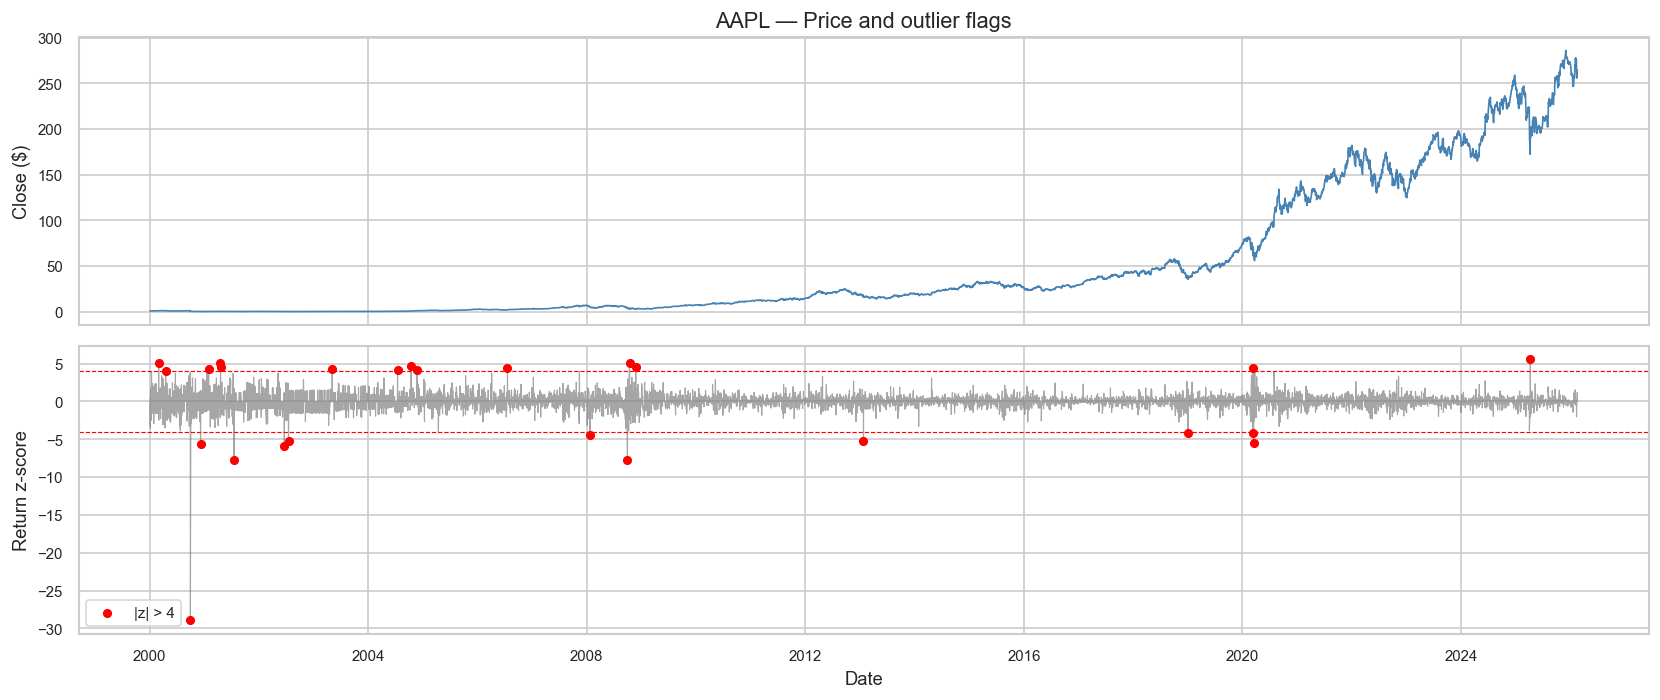


Interpretation:
  - Red dots on the z-score chart mark days where the return was statistically
    extreme for that specific ticker.
  - Cross-referencing with the price chart: if a dot-com era spike aligns with
    a known earnings event, it is legitimate signal.
  - If a spike has no corresponding price-level move visible on the top chart
    (implying a one-day error then reversion), that is a data quality problem.



In [49]:
# ── 6.5  Outlier visualisation — return z-scores over time ────────────────────
ref = SAMPLE_TICKERS[0]
sub = df[df['Ticker'] == ref].set_index('Date')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(sub.index, sub['Close'], lw=1, color='steelblue')
ax1.set_ylabel('Close ($)')
ax1.set_title(f'{ref} — Price and outlier flags')

outlier_days = sub[sub['Return_Zscore'].abs() > Z_THRESH]
ax2.plot(sub.index, sub['Return_Zscore'], lw=0.7, color='gray', alpha=0.7)
ax2.scatter(outlier_days.index, outlier_days['Return_Zscore'],
            color='red', s=20, zorder=5, label=f'|z| > {Z_THRESH}')
ax2.axhline(Z_THRESH, color='red', lw=0.7, linestyle='--')
ax2.axhline(-Z_THRESH, color='red', lw=0.7, linestyle='--')
ax2.set_ylabel('Return z-score')
ax2.set_xlabel('Date')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Red dots on the z-score chart mark days where the return was statistically
    extreme for that specific ticker.
  - Cross-referencing with the price chart: if a dot-com era spike aligns with
    a known earnings event, it is legitimate signal.
  - If a spike has no corresponding price-level move visible on the top chart
    (implying a one-day error then reversion), that is a data quality problem.
""")

In [50]:
# ── 6.6  Summary table — EDA findings ────────────────────────────────────────
summary = {
    'Metric': [
        'Total rows', 'Unique tickers', 'Date range', 'Missing values',
        'Zero-volume rows', 'Return outliers (|z|>4)', 'Return skewness',
        'Return excess kurtosis', 'Median annualised vol'
    ],
    'Value': [
        f'{len(df):,}',
        str(df["Ticker"].nunique()),
        f'{df["Date"].min().date()} → {df["Date"].max().date()}',
        str(df.isnull().sum().sum()),
        str(len(df[df['Volume'] == 0])),
        str(len(outliers)),
        f'{returns.skew():.3f}',
        f'{returns.kurtosis():.3f}',
        f'{vol_data.median():.3f}'
    ]
}
pd.DataFrame(summary)

,Metric,Value
0,Total rows,"514,075"
1,Unique tickers,100
2,Date range,2000-01-03 → 2026-02-18
3,Missing values,3200
4,Zero-volume rows,1594
5,Return outliers (|z|>4),3517
6,Return skewness,-0.845
7,Return excess kurtosis,54.816
8,Median annualised vol,0.299


---
## EDA Conclusions

| Finding | Preprocessing implication |
|---|---|
| Prices are right-skewed | Use log prices / log returns as model inputs |
| Returns have fat tails (kurtosis >> 0) | Use Huber/quantile loss; winsorise at 1st/99th pct |
| Volume is right-skewed | Use log₁₀(volume) as feature |
| OHLC columns are highly correlated | Use derived features instead of raw OHLC |
| Cross-ticker correlations cluster by sector | Exploit as item-similarity in RecSys |
| Some tickers have shorter histories | Filter or impute; document survivorship bias |
| Zero-volume rows exist | Replace with NaN; forward-fill short gaps |
| Outlier returns are mostly real market events | Winsorise rather than remove |

**Next step:** `1.1-B Data Preparation` — build the feature matrix using these findings.